## Exploratory Data Analysis

### EDA 1 — Dataset Overview and Data Quality

The dataset is first inspected to understand its size, feature structure, data types, missing values, duplicate records and the number of unique values in each attribute. This provides the basis for subsequent preprocessing and class-distribution analysis.

In [ ]:
# ============================================
# CELL 1 - Setup and dataset paths
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Current notebook is inside /notebooks
NOTEBOOK_DIR = Path.cwd()

# Go back one level to repository root
PROJECT_DIR = NOTEBOOK_DIR.parent

# Dataset location
DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_CSV = TRAIN_DIR / "styles_train.csv"
PREDICTION_CSV = TEST_DIR / "styles_prediction_template.csv"

TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"
TEST_IMAGE_DIR = TEST_DIR / "images_test"

# Processed data folder
PROCESSED_DIR = DATASET_ROOT / "processed"

print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)

Notebook directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\notebooks
Project directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System
Dataset directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\FashionDataset


In [2]:
# ============================================
# CELL 2 - Check dataset paths
# ============================================

print("Train CSV exists:", TRAIN_CSV.exists())
print("Prediction CSV exists:", PREDICTION_CSV.exists())
print("Train image folder exists:", TRAIN_IMAGE_DIR.exists())
print("Test image folder exists:", TEST_IMAGE_DIR.exists())

assert TRAIN_CSV.exists(), f"Cannot find {TRAIN_CSV}"
assert PREDICTION_CSV.exists(), f"Cannot find {PREDICTION_CSV}"
assert TRAIN_IMAGE_DIR.exists(), f"Cannot find {TRAIN_IMAGE_DIR}"
assert TEST_IMAGE_DIR.exists(), f"Cannot find {TEST_IMAGE_DIR}"

print("\nAll dataset paths found successfully.")

Train CSV exists: True
Prediction CSV exists: True
Train image folder exists: True
Test image folder exists: True

All dataset paths found successfully.


In [3]:
# ============================================
# CELL 3 - Load metadata
# ============================================

train = pd.read_csv(TRAIN_CSV)
prediction = pd.read_csv(PREDICTION_CSV)

print("Training dataset shape:", train.shape)
print("Prediction dataset shape:", prediction.shape)

display(train.head())
display(prediction.head())

Training dataset shape: (38617, 12)
Prediction dataset shape: (5829, 5)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,NaN,NaN
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,NaN,NaN


,id,gender,articleType,season,usage
0,52003,NaN,NaN,NaN,NaN
1,52007,NaN,NaN,NaN,NaN
2,52017,NaN,NaN,NaN,NaN
3,52021,NaN,NaN,NaN,NaN
4,52023,NaN,NaN,NaN,NaN


### Data Quality Fix — comma-split product names

`productDisplayName` contains unquoted commas in a small number of rows, so the tail of the
name was pushed into the trailing `Unnamed:` columns by the CSV parser. Dropping those columns
would silently truncate the affected names, so the fragments are re-joined first and only then
are the empty columns removed.

In [4]:
# ============================================
# CELL 3b - Repair comma-split productDisplayName
# ============================================

extra_columns = [c for c in train.columns if c.startswith("Unnamed")]
print("Phantom columns found:", extra_columns)

affected_mask = train[extra_columns].notna().any(axis=1)
print("Rows affected by unquoted commas:", int(affected_mask.sum()))

display(
    train.loc[affected_mask, ["id", "articleType", "productDisplayName"] + extra_columns]
    .head(21)
)


def rejoin_product_name(row):
    fragments = [row["productDisplayName"]] + [row[c] for c in extra_columns]
    fragments = [
        str(f).strip()
        for f in fragments
        if pd.notna(f) and str(f).strip() != ""
    ]
    return ", ".join(fragments) if fragments else np.nan


train["productDisplayName"] = train.apply(rejoin_product_name, axis=1)
train = train.drop(columns=extra_columns)

print("\nShape after repair:", train.shape)
print("Columns:", train.columns.tolist())

display(train.loc[affected_mask, ["id", "productDisplayName"]])

Phantom columns found: ['Unnamed: 10', 'Unnamed: 11']
Rows affected by unquoted commas: 21


,id,articleType,productDisplayName,Unnamed: 10,Unnamed: 11
1320,3413,Tshirts,Myntra Men's Yes,its all about me White T-shirt,NaN
1325,3418,Tshirts,Myntra Men's Take my advice,I don't use it anyway Black T-shirt,NaN
1335,3428,Tshirts,Myntra Mens Be Reasonable,Do It My Way T-shirt,NaN
2689,4854,Casual Shoes,Newfeel Unisex White,Blue and Orange Casual Shoes,NaN
17899,23100,Accessory Gift Set,Turtle Men Formal Navy Blue Tie,Cufflink and Pocket Square Combo Set,NaN
17900,23101,Accessory Gift Set,Turtle Men Formal Pink Tie,Cufflink and Pocket Square Combo Set,NaN
17902,23103,Accessory Gift Set,Turtle Men Formal Black Tie,Cufflink and Pocket Square Combo Set,NaN
17906,23107,Accessory Gift Set,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17907,23108,Accessory Gift Set,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17908,23109,Accessory Gift Set,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN



Shape after repair: (38617, 10)
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,productDisplayName
1320,3413,"Myntra Men's Yes, its all about me White T-shirt"
1325,3418,"Myntra Men's Take my advice, I don't use it an..."
1335,3428,"Myntra Mens Be Reasonable, Do It My Way T-shirt"
2689,4854,"Newfeel Unisex White, Blue and Orange Casual S..."
17899,23100,"Turtle Men Formal Navy Blue Tie, Cufflink and ..."
17900,23101,"Turtle Men Formal Pink Tie, Cufflink and Pocke..."
17902,23103,"Turtle Men Formal Black Tie, Cufflink and Pock..."
17906,23107,"Turtle Men Formal Purple Tie, Cufflink and Poc..."
17907,23108,"Turtle Men Formal Purple Tie, Cufflink and Poc..."
17908,23109,"Turtle Men Formal Purple Tie, Cufflink and Poc..."


In [5]:
# ============================================
# CELL 3c - Verify the repair
# ============================================

assert not [c for c in train.columns if c.startswith("Unnamed")], \
    "Phantom columns still present"
assert train.shape[1] == 10, f"Expected 10 columns, got {train.shape[1]}"

# The repaired names must now contain the comma that caused the split
repaired = train.loc[affected_mask, "productDisplayName"]
print("Repaired names containing a comma:", int(repaired.str.contains(",").sum()), "/", len(repaired))
print("\nMissing values after repair:")
display(train.isna().sum()[lambda s: s > 0].to_frame("Missing Count"))

Repaired names containing a comma: 21 / 21

Missing values after repair:


,Missing Count
baseColour,14
season,20
usage,72
productDisplayName,7


In [6]:
# ============================================
# CELL 4 - Inspect dataset columns
# ============================================

print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nPREDICTION COLUMNS")
print(prediction.columns.tolist())

TRAIN COLUMNS
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

PREDICTION COLUMNS
['id', 'gender', 'articleType', 'season', 'usage']


In [7]:
# ============================================
# CELL 5 - Basic dataset information
# ============================================

print("=" * 60)
print("TRAINING DATASET")
print("=" * 60)

print("Rows:", len(train))
print("Columns:", len(train.columns))

print("\nData types:")
display(train.dtypes.to_frame("Data Type"))

print("\nMissing values:")
missing_values = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_values[
        missing_values > 0
    ].to_frame("Missing Count")
)

TRAINING DATASET
Rows: 38617
Columns: 10

Data types:


,Data Type
id,int64
gender,object
masterCategory,object
subCategory,object
articleType,object
baseColour,object
season,object
year,int64
usage,object
productDisplayName,object



Missing values:


,Missing Count
usage,72
season,20
baseColour,14
productDisplayName,7


### Duplicate records, category consistency and outliers

Duplicate product entries matter because near-identical items must not be split across
training and validation. Category values are also checked for whitespace and casing artefacts
that would otherwise split one real class into two label ids, followed by outlier analysis of
the numeric and text fields.

In [8]:
# ============================================
# CELL 5b - Duplicate record checks
# ============================================

print("Duplicate ids                  :", int(train["id"].duplicated().sum()))
print("Fully duplicated rows          :", int(train.duplicated().sum()))
print("Duplicated rows ignoring id    :", int(train.drop(columns=["id"]).duplicated().sum()))

name_counts = train["productDisplayName"].value_counts()
repeated_names = name_counts[name_counts > 1]

print("\nDistinct product names repeated:", len(repeated_names))
print("Rows sharing a name with another:",
      int(train["productDisplayName"].duplicated(keep=False).sum()))

display(repeated_names.head(10).to_frame("Count"))

Duplicate ids                  : 0
Fully duplicated rows          : 0
Duplicated rows ignoring id    : 8972

Distinct product names repeated: 4447
Rows sharing a name with another: 15513


,Count
productDisplayName,
Lucera Women Silver Earrings,82
Lucera Women Silver Pendant,56
Lucera Women Silver Ring,49
Catwalk Women Black Heels,43
Q&Q Men Black Dial Watch,39
Fabindia Women Anusuya Silver Earrings,37
Maxima Men White Dial Watch,34
Coolers Men Black Sandals,31
Lucera Women Silver Pendant with Chain,28


In [9]:
# ============================================
# CELL 5c - Do repeated names carry conflicting labels?
# ============================================

conflicts = (
    train[train["productDisplayName"].isin(repeated_names.index)]
    .groupby("productDisplayName")[["articleType", "season", "gender", "usage"]]
    .nunique()
)

print("Repeated-name groups with more than one distinct label:")
display((conflicts > 1).sum().to_frame("Groups with conflict"))

# Worst offender - useful example for the report
worst = conflicts["season"].sort_values(ascending=False).head(1)
if worst.iloc[0] > 1:
    display(train[train["productDisplayName"] == worst.index[0]]
            [["id", "articleType", "season", "gender", "usage"]])

Repeated-name groups with more than one distinct label:


,Groups with conflict
articleType,109
season,907
gender,2
usage,282


,id,articleType,season,gender,usage
8143,11279,Jeans,Fall,Men,Casual
8145,11281,Jeans,Summer,Men,Casual
8146,11282,Jeans,Summer,Men,Casual
8147,11283,Jeans,Winter,Men,Casual
8148,11284,Jeans,Fall,Men,Casual
8149,11285,Jeans,Summer,Men,Casual
8151,11287,Jeans,Summer,Men,Casual
8152,11288,Jeans,Fall,Men,Casual
8153,11289,Jeans,Spring,Men,Casual
8157,11293,Jeans,Fall,Men,Casual


In [10]:
# ============================================
# CELL 5d - Categorical consistency checks
# ============================================

import re

CATEGORICAL_COLUMNS = [
    "gender", "masterCategory", "subCategory",
    "articleType", "baseColour", "season", "usage"
]

consistency_rows = []

for column in CATEGORICAL_COLUMNS:
    values = train[column].dropna().astype(str)
    consistency_rows.append({
        "Column": column,
        "Unique": values.nunique(),
        "LeadingTrailingSpace": int((values != values.str.strip()).sum()),
        "DoubleSpace": int(values.str.contains("  ").sum()),
        "CaseOnlyDuplicates": values.nunique() - values.str.lower().str.strip().nunique(),
        "EmptyString": int((values.str.strip() == "").sum()),
    })

display(pd.DataFrame(consistency_rows))

# Normalise whitespace (safe even if the counts above are all zero)
for column in CATEGORICAL_COLUMNS:
    train[column] = train[column].apply(
        lambda v: re.sub(r"\s+", " ", v).strip() if isinstance(v, str) else v
    )
print("Whitespace normalised.")

,Column,Unique,LeadingTrailingSpace,DoubleSpace,CaseOnlyDuplicates,EmptyString
0,gender,5,0,0,0,0
1,masterCategory,7,0,0,0,0
2,subCategory,41,0,0,0,0
3,articleType,125,0,0,0,0
4,baseColour,46,0,0,0,0
5,season,4,0,0,0,0
6,usage,8,0,0,0,0


Whitespace normalised.


IQR bounds: [2008, 2016]
IQR outliers  : 1734 (4.49%)
|z| > 3       : 0
Implausible years (<1990 or future): 0


,Count
year,
2007,2
2008,7
2009,20
2010,805
2011,13689
2012,13361
2013,1116
2014,174
2015,2348


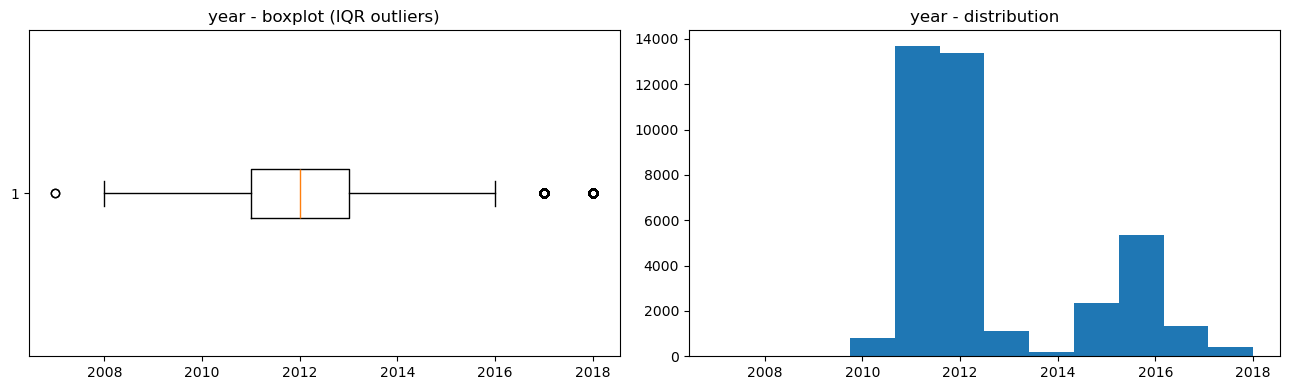

In [11]:
# ============================================
# CELL 5e - Outlier analysis (year and text length)
# ============================================

# `id` is an identifier, not a measurement, so it is excluded from outlier logic.
year_values = train["year"].dropna()

q1, q3 = year_values.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

iqr_outliers = train[(train["year"] < lower_bound) | (train["year"] > upper_bound)]
z_scores = (train["year"] - year_values.mean()) / year_values.std()

print(f"IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print("IQR outliers  :", len(iqr_outliers),
      f"({len(iqr_outliers) / len(train) * 100:.2f}%)")
print("|z| > 3       :", int((z_scores.abs() > 3).sum()))
print("Implausible years (<1990 or future):",
      int(((train["year"] < 1990) | (train["year"] > pd.Timestamp.now().year)).sum()))

display(train["year"].value_counts().sort_index().to_frame("Count"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(train["year"].dropna(), vert=False)
axes[0].set_title("year - boxplot (IQR outliers)")
axes[1].hist(train["year"].dropna(), bins=train["year"].nunique())
axes[1].set_title("year - distribution")
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# CELL 5f - Product name length outliers
# ============================================

train["name_length"] = train["productDisplayName"].fillna("").str.len()
train["name_words"] = train["productDisplayName"].fillna("").str.split().str.len()

display(train[["name_length", "name_words"]].describe())

print("Shortest product names (possible truncation):")
display(train.nsmallest(10, "name_length")[["id", "productDisplayName", "articleType"]])

print("Longest product names:")
display(train.nlargest(5, "name_length")[["id", "productDisplayName"]])

train = train.drop(columns=["name_length", "name_words"])

,name_length,name_words
count,38617.000000,38617.000000
mean,34.951343,5.839941
std,8.263919,1.361290
min,0.000000,0.000000
25%,29.000000,5.000000
50%,34.000000,6.000000
75%,40.000000,7.000000
max,82.000000,14.000000


Shortest product names (possible truncation):


,id,productDisplayName,articleType
23884,30991,NaN,Perfume and Body Mist
23885,30992,NaN,Perfume and Body Mist
31966,42863,NaN,Clutches
31981,42878,NaN,Clutches
32186,43119,NaN,Perfume and Body Mist
34123,45687,NaN,Perfume and Body Mist
34128,45698,NaN,Perfume and Body Mist
35342,47238,Playboy,Casual Shoes
6,1529,Ferrari Tee,Tshirts
25430,33292,Arrow Sport,Shirts


Longest product names:


,id,productDisplayName
29794,39405,U.S. Polo Assn. Men Lavender & White Striped L...
9651,12988,United Colors Of Benetton Women Womenlight Win...
33743,45148,Casio Enticer Men Silver-Gold Analogue Multi-D...
33856,45269,CASIO Youth Series Digital Men Black Small Dia...
32435,43437,Global Desi Women Pink & Orange Printed Anarka...


In [13]:
# ============================================
# CELL 6 - Inspect assignment targets
# ============================================

target_columns = [
    "articleType",
    "season",
    "gender",
    "usage"
]

for column in target_columns:

    print("\n" + "=" * 60)
    print(column.upper())
    print("=" * 60)

    print(
        "Number of classes:",
        train[column].nunique(dropna=True)
    )

    print(
        "Missing values:",
        train[column].isna().sum()
    )

    display(
        train[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


ARTICLETYPE
Number of classes: 125
Missing values: 0


,Count
articleType,
Tshirts,6781
Shirts,3089
Casual Shoes,2683
Watches,2252
Sports Shoes,1991
...,...
Ipad,1
Body Wash and Scrub,1
Ties and Cufflinks,1



SEASON
Number of classes: 4
Missing values: 20


,Count
season,
Summer,19137
Fall,10512
Winter,7381
Spring,1567
NaN,20



GENDER
Number of classes: 5
Missing values: 0


,Count
gender,
Men,20918
Women,14160
Unisex,2080
Boys,814
Girls,645



USAGE
Number of classes: 8
Missing values: 72


,Count
usage,
Casual,29641
Sports,3940
Ethnic,2570
Formal,2300
NaN,72
Smart Casual,55
Travel,25
Party,13
Home,1


In [14]:
# ============================================
# CELL 7 - Target class imbalance
# ============================================

target_columns = ["articleType", "season", "gender", "usage"]

for target in target_columns:
    counts = train[target].value_counts(dropna=True)
    percentages = train[target].value_counts(normalize=True, dropna=True) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print("\n" + "=" * 60)
    print(target.upper())
    print("=" * 60)
    display(summary.head(15))

    print("Largest class percentage:", round(percentages.iloc[0], 2), "%")
    print("Smallest class count:", counts.iloc[-1])


ARTICLETYPE


,Count,Percentage
articleType,,
Tshirts,6781,17.56
Shirts,3089,8.00
Casual Shoes,2683,6.95
Watches,2252,5.83
Sports Shoes,1991,5.16
Tops,1614,4.18
Kurtas,1556,4.03
Handbags,1439,3.73
Heels,1048,2.71


Largest class percentage: 17.56 %
Smallest class count: 1

SEASON


,Count,Percentage
season,,
Summer,19137,49.58
Fall,10512,27.24
Winter,7381,19.12
Spring,1567,4.06


Largest class percentage: 49.58 %
Smallest class count: 1567

GENDER


,Count,Percentage
gender,,
Men,20918,54.17
Women,14160,36.67
Unisex,2080,5.39
Boys,814,2.11
Girls,645,1.67


Largest class percentage: 54.17 %
Smallest class count: 645

USAGE


,Count,Percentage
usage,,
Casual,29641,76.90
Sports,3940,10.22
Ethnic,2570,6.67
Formal,2300,5.97
Smart Casual,55,0.14
Travel,25,0.06
Party,13,0.03
Home,1,0.00


Largest class percentage: 76.9 %
Smallest class count: 1


### Majority-class baselines

Each target has a constant-predictor accuracy that any trained model must exceed. These values
define the minimum acceptable performance and motivate reporting macro-F1 and balanced accuracy
alongside plain accuracy.

In [15]:
# ============================================
# CELL 7b - Majority-class baseline accuracy
# ============================================

baseline_rows = []

for target in target_columns:
    distribution = train[target].value_counts(normalize=True, dropna=True)
    baseline_rows.append({
        "Target": target,
        "Classes": train[target].nunique(),
        "MajorityClass": distribution.index[0],
        "BaselineAccuracy%": round(distribution.iloc[0] * 100, 2),
        "ImbalanceRatio": round(
            train[target].value_counts().iloc[0] / train[target].value_counts().iloc[-1], 1
        ),
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

print("Any model scoring below its BaselineAccuracy% is worse than a constant predictor.")
print("Because of this, report macro-F1 and balanced accuracy alongside plain accuracy,")
print("especially for `usage` where the majority class alone reaches ~77%.")

,Target,Classes,MajorityClass,BaselineAccuracy%,ImbalanceRatio
0,articleType,125,Tshirts,17.56,6781.0
1,season,4,Summer,49.58,12.2
2,gender,5,Men,54.17,32.4
3,usage,8,Casual,76.90,29641.0


Any model scoring below its BaselineAccuracy% is worse than a constant predictor.
Because of this, report macro-F1 and balanced accuracy alongside plain accuracy,
especially for `usage` where the majority class alone reaches ~77%.


## EDA 2 — Image Data Inspection

The image dataset is inspected to verify file availability, consistency between metadata IDs and image files, and the general visual characteristics of the fashion images before defining the image preprocessing pipeline.

In [16]:
# ============================================
# CELL 8 - Match metadata IDs with image files
# ============================================

train_image_files = list(TRAIN_IMAGE_DIR.glob("*"))
test_image_files = list(TEST_IMAGE_DIR.glob("*"))

print("Training image files:", len(train_image_files))
print("Test image files:", len(test_image_files))

train_image_ids = {p.stem for p in train_image_files}
test_image_ids = {p.stem for p in test_image_files}

train_ids = set(train["id"].astype(str))
test_ids = set(prediction["id"].astype(str))

print("\nTrain IDs with image:", len(train_ids & train_image_ids))
print("Train IDs without image:", len(train_ids - train_image_ids))

print("\nTest IDs with image:", len(test_ids & test_image_ids))
print("Test IDs without image:", len(test_ids - test_image_ids))

Training image files: 38613
Test image files: 5829

Train IDs with image: 38612
Train IDs without image: 5

Test IDs with image: 5829
Test IDs without image: 0


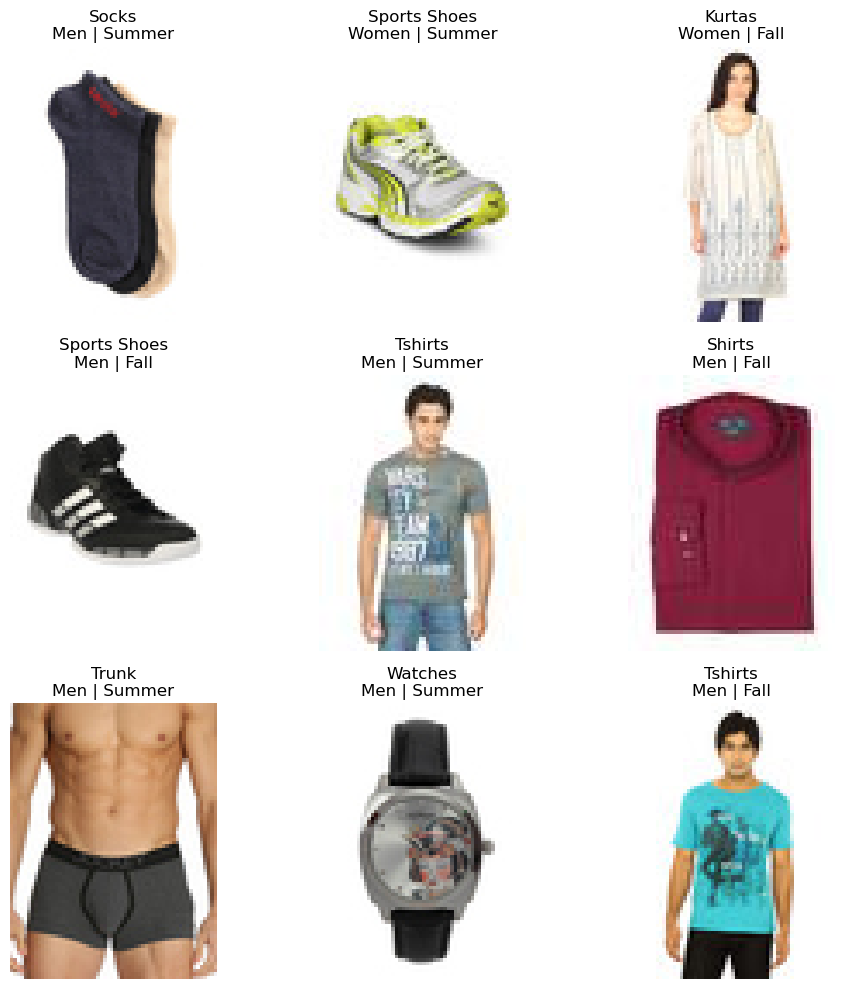

In [17]:
# ============================================
# CELL 9 - Visual inspection of training images
# ============================================

from PIL import Image

sample_rows = train.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    image_path = TRAIN_IMAGE_DIR / f"{row['id']}.jpg"

    if image_path.exists():
        image = Image.open(image_path)
        ax.imshow(image)
        ax.set_title(
            f"{row['articleType']}\n"
            f"{row['gender']} | {row['season']}"
        )
    else:
        ax.set_title(f"Image missing: {row['id']}")

    ax.axis("off")

plt.tight_layout()
plt.show()

## EDA 3 — Image Dimensions and Quality Checks

Training images are inspected to understand image dimensions, colour modes, and possible corrupted files. These checks help define a consistent preprocessing strategy before model training.

Image properties are scanned across **all** training images rather than a fixed slice of the
directory listing, because directory order is not random. `Image.open()` reads only the file
header, so the full scan is inexpensive and the result is cached to `processed/image_scan.csv`.

In [18]:
# ============================================
# CELL 11b - Full image property scan (replaces CELL 11)
# ============================================

from collections import Counter
from PIL import Image

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
SCAN_CACHE = PROCESSED_DIR / "image_scan.csv"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

image_files = [
    p for p in TRAIN_IMAGE_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
]
skipped_files = [
    p.name for p in TRAIN_IMAGE_DIR.iterdir()
    if p.suffix.lower() not in VALID_EXTENSIONS
]
print("Image files:", len(image_files), "| Non-image files skipped:", skipped_files)

if SCAN_CACHE.exists():
    image_scan = pd.read_csv(SCAN_CACHE)
    print("Loaded cached scan from", SCAN_CACHE)
else:
    scan_records = []
    for count, path in enumerate(image_files, start=1):
        record = {"id": path.stem, "readable": False, "width": np.nan,
                  "height": np.nan, "mode": None, "bytes": np.nan, "error": None}
        try:
            record["bytes"] = path.stat().st_size
            with Image.open(path) as img:
                record["width"], record["height"], record["mode"] = img.width, img.height, img.mode
            with Image.open(path) as img:
                img.verify()
            record["readable"] = True
        except Exception as error:
            record["error"] = f"{type(error).__name__}: {error}"
        scan_records.append(record)
        if count % 10000 == 0:
            print(f"  scanned {count}/{len(image_files)}")
    image_scan = pd.DataFrame(scan_records)
    image_scan.to_csv(SCAN_CACHE, index=False)
    print("Saved scan to", SCAN_CACHE)

print("\nReadable:", int(image_scan["readable"].sum()),
      "| Unreadable:", int((~image_scan["readable"]).sum()))

Image files: 38612 | Non-image files skipped: ['.DS_Store']
Loaded cached scan from c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed\image_scan.csv

Readable: 38612 | Unreadable: 0


In [19]:
# ============================================
# CELL 11c - Resolution and colour mode over ALL images
# ============================================

print("Resolutions:")
display(
    image_scan.groupby(["width", "height"]).size()
    .sort_values(ascending=False).head(10).to_frame("Count")
)

print("Colour modes:")
display(image_scan["mode"].value_counts().to_frame("Count"))

non_rgb = image_scan[image_scan["mode"] != "RGB"]
print(f"\nNon-RGB images: {len(non_rgb)} "
      f"({len(non_rgb) / len(image_scan) * 100:.2f}%)")
display(non_rgb.head())

modal_size = (int(image_scan["width"].mode()[0]), int(image_scan["height"].mode()[0]))
off_size = image_scan[
    (image_scan["width"] != modal_size[0]) | (image_scan["height"] != modal_size[1])
]
print(f"\nModal resolution: {modal_size[0]} x {modal_size[1]}")
print(f"Images NOT at the modal resolution: {len(off_size)}")
display(off_size[["id", "width", "height", "mode"]].head(10))

Resolutions:


Count
width height       
60    80      38595
53    80          8
60    60          5
      77          2
      75          1
      76          1

Colour modes:


,Count
mode,
RGB,38269
L,343



Non-RGB images: 343 (0.89%)


,id,readable,width,height,mode,bytes,error
588,10705,True,60,80,L,1636,NaN
599,10716,True,60,80,L,1166,NaN
604,10721,True,60,80,L,1608,NaN
1200,11489,True,60,80,L,1678,NaN
2531,12994,True,60,80,L,14544,NaN



Modal resolution: 60 x 80
Images NOT at the modal resolution: 17


,id,width,height,mode
911,11151,60,77,RGB
920,11160,60,77,RGB
3991,14776,60,76,RGB
6882,1799,60,60,RGB
6893,1800,60,60,RGB
6904,1801,60,60,RGB
11343,2311,60,60,RGB
13080,25299,53,80,RGB
13660,25943,53,80,RGB
13675,25958,53,80,RGB


In [20]:
# ============================================
# CELL 12 - Image dimension summary
# ============================================

image_dimension_df = (
    image_scan[["width", "height"]]
    .rename(columns={"width": "Width", "height": "Height"})
)

display(image_dimension_df.describe())

print("Unique image sizes:", image_dimension_df.drop_duplicates().shape[0])

display(
    image_dimension_df.value_counts()
    .head(10)
    .to_frame("Count")
)

,Width,Height
count,38612.000000,38612.000000
mean,59.998550,79.997022
std,0.100749,0.230907
min,53.000000,60.000000
25%,60.000000,80.000000
50%,60.000000,80.000000
75%,60.000000,80.000000
max,60.000000,80.000000


Unique image sizes: 6


Count
Width Height       
60    80      38595
53    80          8
60    60          5
      77          2
      75          1
      76          1

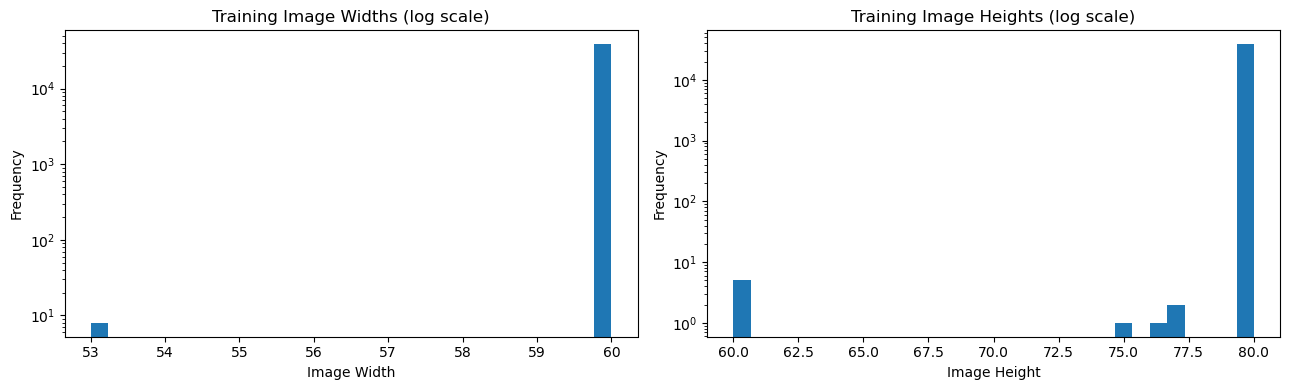

A log-scaled y-axis is used because the resolution distribution is dominated by a
single modal size; a linear axis would hide the small number of off-spec images.


In [21]:
# ============================================
# CELL 13 - Image dimension distributions
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(image_dimension_df["Width"].dropna(), bins=30)
axes[0].set_xlabel("Image Width")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].set_title("Training Image Widths (log scale)")

axes[1].hist(image_dimension_df["Height"].dropna(), bins=30)
axes[1].set_xlabel("Image Height")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].set_title("Training Image Heights (log scale)")

plt.tight_layout()
plt.show()

print("A log-scaled y-axis is used because the resolution distribution is dominated by a")
print("single modal size; a linear axis would hide the small number of off-spec images.")

The integrity results from the scan above are now used to build an explicit exclusion list,
rather than being reported and then discarded. Files that are not images (for example
`.DS_Store`) are separated from files that are genuinely unreadable.

In [22]:
# ============================================
# CELL 14b - Corrupt images, filtered by extension
# ============================================

unreadable = image_scan[~image_scan["readable"]]

print("Non-image files in the folder (not corruption):", skipped_files)
print("Genuinely unreadable image files:", len(unreadable))
if len(unreadable):
    display(unreadable[["id", "error"]])

# ids that must be excluded downstream
UNREADABLE_IDS = set(unreadable["id"].astype(str))
print("\nIds to exclude from clean_train:", len(UNREADABLE_IDS))

Non-image files in the folder (not corruption): ['.DS_Store']
Genuinely unreadable image files: 0

Ids to exclude from clean_train: 0


 ## EDA 4 — Label Quality and Rare Classes

The target variables are inspected for missing labels and extremely rare classes. These issues are important because each prediction task requires a different target-specific training subset and stratified validation strategy.

In [23]:
# ============================================
# CELL 15 - Missing labels and rare classes
# ============================================

target_columns = [
    "articleType",
    "season",
    "gender",
    "usage"
]

rare_class_summary = []

for target in target_columns:
    counts = train[target].value_counts(dropna=True)

    rare_classes_1 = counts[counts == 1]
    rare_classes_5 = counts[counts <= 5]
    rare_classes_10 = counts[counts <= 10]

    rare_class_summary.append({
        "Target": target,
        "Classes": len(counts),
        "MissingLabels": train[target].isna().sum(),
        "ClassesWith1Sample": len(rare_classes_1),
        "ClassesWith5OrFewer": len(rare_classes_5),
        "ClassesWith10OrFewer": len(rare_classes_10)
    })

rare_class_summary = pd.DataFrame(rare_class_summary)

display(rare_class_summary)

,Target,Classes,MissingLabels,ClassesWith1Sample,ClassesWith5OrFewer,ClassesWith10OrFewer
0,articleType,125,0,7,24,33
1,season,4,20,0,0,0
2,gender,5,0,0,0,0
3,usage,8,72,1,1,1


### Label integrity

`masterCategory` -> `subCategory` -> `articleType` is expected to be a strict hierarchy. Any
`articleType` associated with more than one parent category is a labelling inconsistency, which
places an upper bound on achievable accuracy and should be reported as such.

In [24]:
# ============================================
# CELL 15b - Category hierarchy integrity
# ============================================

hierarchy = train.groupby("articleType")[["subCategory", "masterCategory"]].nunique()
inconsistent = hierarchy[(hierarchy["subCategory"] > 1) | (hierarchy["masterCategory"] > 1)]

print("articleType values mapping to more than one parent category:", len(inconsistent))
display(inconsistent.sort_values("subCategory", ascending=False))

if len(inconsistent):
    example = inconsistent.index[0]
    print(f"Example - '{example}':")
    display(
        train[train["articleType"] == example]
        .groupby(["masterCategory", "subCategory"]).size().to_frame("Count")
    )

articleType values mapping to more than one parent category: 20


,subCategory,masterCategory
articleType,,
Wallets,3,2
Backpacks,2,2
Belts,2,2
Water Bottle,2,1
Tshirts,2,2
Travel Accessory,2,1
Ties,2,2
Swimwear,2,1
Shorts,2,1


Example - 'Backpacks':


,,Count
masterCategory,subCategory,
Accessories,Bags,708
Free Items,Free Gifts,2


In [25]:
# ============================================
# CELL 15c - Cross-tabulations for label sanity
# ============================================

print("gender x masterCategory")
display(pd.crosstab(train["gender"], train["masterCategory"]))

print("season x usage")
display(pd.crosstab(train["season"], train["usage"]))

print("season proportions by year (is label quality stable over time?)")
display(pd.crosstab(train["year"], train["season"], normalize="index").round(3))

gender x masterCategory


masterCategory,Accessories,Apparel,Footwear,Free Items,Home,Personal Care,Sporting Goods
gender,,,,,,,
Boys,17,743,54,0,0,0,0
Girls,27,558,60,0,0,0,0
Men,3994,10875,5480,42,0,527,0
Unisex,1447,85,507,3,1,12,25
Women,4334,6886,2440,38,0,462,0


season x usage


usage,Casual,Ethnic,Formal,Home,Party,Smart Casual,Sports,Travel
season,,,,,,,,
Fall,7037,862,970,1,1,13,1617,0
Spring,1371,4,37,0,2,3,109,2
Summer,14351,1612,1048,0,6,9,2081,11
Winter,6882,92,245,0,4,30,113,12


season proportions by year (is label quality stable over time?)


season,Fall,Spring,Summer,Winter
year,,,,
2007,0.000,1.000,0.000,0.000
2008,0.143,0.429,0.286,0.143
2009,0.950,0.000,0.050,0.000
2010,0.793,0.004,0.117,0.087
2011,0.640,0.006,0.343,0.011
2012,0.072,0.008,0.855,0.065
2013,0.059,0.316,0.581,0.044
2014,0.172,0.075,0.494,0.259
2015,0.012,0.001,0.105,0.882


## Shared Data Preprocessing

Only records with available image files are retained for image-based modelling. Image paths are then created for both training and unseen test observations. Target-specific missing labels are not removed here because each prediction task will construct its own modelling subset.


In [26]:
# ============================================
# CELL 16 - Create cleaned training metadata
# ============================================

valid_extensions = {".jpg", ".jpeg", ".png"}

valid_train_image_ids = {
    path.stem
    for path in TRAIN_IMAGE_DIR.iterdir()
    if path.suffix.lower() in valid_extensions
}

clean_train = train[
    train["id"].astype(str).isin(valid_train_image_ids)
].copy()

print("Original training rows:", len(train))
print("Rows with available images:", len(clean_train))
print(
    "Rows removed because image is missing:",
    len(train) - len(clean_train)
)

expected_rows = len(train) - len(set(train["id"].astype(str)) - valid_train_image_ids)
assert len(clean_train) == expected_rows, (
    f"Expected {expected_rows} rows, got {len(clean_train)}"
)

Original training rows: 38617
Rows with available images: 38612
Rows removed because image is missing: 5


In [27]:
# ============================================
# CELL 17 - Add image paths
# ============================================

clean_train["image_path"] = clean_train["id"].apply(
    lambda image_id:
    str(TRAIN_IMAGE_DIR / f"{image_id}.jpg")
)

prediction["image_path"] = prediction["id"].apply(
    lambda image_id:
    str(TEST_IMAGE_DIR / f"{image_id}.jpg")
)

train_paths_valid = clean_train[
    "image_path"
].apply(
    lambda path: Path(path).exists()
).sum()

test_paths_valid = prediction[
    "image_path"
].apply(
    lambda path: Path(path).exists()
).sum()

print(
    "Valid training image paths:",
    train_paths_valid,
    "/",
    len(clean_train)
)

print(
    "Valid test image paths:",
    test_paths_valid,
    "/",
    len(prediction)
)

assert train_paths_valid == len(clean_train)
assert test_paths_valid == len(prediction)

Valid training image paths: 38612 / 38612
Valid test image paths: 5829 / 5829


### Duplicate images and leakage-safe splitting

Repeated product entries frequently correspond to byte-identical or near-identical photographs.
If copies of the same item appear in both the training and validation split, validation accuracy
is optimistically biased. Splits are therefore grouped by product name as well as stratified by
the target.

In [28]:
# ============================================
# CELL 16b - Exact duplicate image detection (content hash)
# ============================================

import hashlib

HASH_CACHE = PROCESSED_DIR / "image_hashes.csv"

if HASH_CACHE.exists():
    image_hashes = pd.read_csv(HASH_CACHE, dtype={"id": str})
else:
    hash_records = []
    for count, path in enumerate(image_files, start=1):
        if path.stem in UNREADABLE_IDS:
            continue
        hash_records.append({
            "id": path.stem,
            "md5": hashlib.md5(path.read_bytes()).hexdigest()
        })
        if count % 10000 == 0:
            print(f"  hashed {count}/{len(image_files)}")
    image_hashes = pd.DataFrame(hash_records)
    image_hashes.to_csv(HASH_CACHE, index=False)

duplicate_hashes = image_hashes["md5"].value_counts()
duplicate_hashes = duplicate_hashes[duplicate_hashes > 1]

print("Groups of byte-identical images:", len(duplicate_hashes))
print("Files involved:", int(duplicate_hashes.sum()))

if len(duplicate_hashes):
    display(image_hashes[image_hashes["md5"] == duplicate_hashes.index[0]])

Groups of byte-identical images: 636
Files involved: 1399


,id,md5
24151,39011,a9ec96a92919d2a196b6f2853d662277
25695,40930,a9ec96a92919d2a196b6f2853d662277
25696,40931,a9ec96a92919d2a196b6f2853d662277
25697,40932,a9ec96a92919d2a196b6f2853d662277


In [29]:
# ============================================
# CELL 16c - Leakage-safe split helper (reuse in every task notebook)
# ============================================

from sklearn.model_selection import StratifiedGroupKFold


def make_grouped_split(df, target, n_splits=6, random_state=42, min_class_size=10):
    """Stratify on `target` while keeping identical product names in one split.

    Returns (train_df, val_df). Classes smaller than `min_class_size` are folded
    into 'Other' so stratification is possible.
    """
    work = df.dropna(subset=[target]).copy()

    counts = work[target].value_counts()
    rare = counts[counts < min_class_size].index
    work["_y"] = work[target].where(~work[target].isin(rare), "Other")

    groups = work["productDisplayName"].fillna(work["id"].astype(str))

    splitter = StratifiedGroupKFold(
        n_splits=n_splits, shuffle=True, random_state=random_state
    )
    train_idx, val_idx = next(splitter.split(work, work["_y"], groups))

    train_part, val_part = work.iloc[train_idx], work.iloc[val_idx]

    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[val_idx])
    assert not overlap, f"Leakage: {len(overlap)} product names in both splits"

    print(f"[{target}] collapsed {len(rare)} rare classes -> 'Other' | "
          f"train={len(train_part)} val={len(val_part)} | "
          f"classes={work['_y'].nunique()} | leakage=0")
    return train_part, val_part


# Sanity check against a naive stratified split
from sklearn.model_selection import train_test_split

subset = train.dropna(subset=["season"])
naive_train, naive_val = train_test_split(
    subset, test_size=0.15, random_state=42, stratify=subset["season"]
)
naive_overlap = set(naive_train["productDisplayName"]) & set(naive_val["productDisplayName"])
print("Product names leaking across a NAIVE stratified split:", len(naive_overlap))

Product names leaking across a NAIVE stratified split: 1657


### Image preprocessing contract

A single loading function is defined and used for both training and test data. Conversion to RGB
is required because some source images are stored in greyscale mode, and an explicit resize is
required because a small number of images do not match the modal resolution.

In [30]:
# ============================================
# CELL 18b - Image loading contract (replaces CELL 18)
# ============================================

IMAGE_WIDTH = 60
IMAGE_HEIGHT = 80
IMAGE_CHANNELS = 3
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)      # (H, W) as used by Keras/PyTorch
PIL_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)        # (W, H) as used by PIL.resize
NORMALISATION_SCALE = 255.0


def load_image(path, size=PIL_SIZE):
    """Single source of truth for image loading - use for train AND test.

    - converts to RGB (required: some source images are greyscale mode 'L')
    - resizes explicitly (required: a few images are not at the modal resolution)
    - returns float32 in [0, 1] with a guaranteed shape
    """
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        array = np.asarray(img, dtype=np.float32) / NORMALISATION_SCALE
    assert array.shape == (IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS), \
        f"Unexpected shape {array.shape} for {path}"
    return array


# Verify the contract holds on the awkward cases, not just typical ones
check_ids = list(off_size["id"].head(5)) + list(non_rgb["id"].head(5))
for image_id in check_ids:
    arr = load_image(TRAIN_IMAGE_DIR / f"{image_id}.jpg")
print(f"load_image() verified on {len(check_ids)} off-spec images -> all "
      f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}x{IMAGE_CHANNELS}")

print("\nPreprocessing contract:")
print("- convert every image to RGB")
print(f"- resize explicitly to {IMAGE_WIDTH} x {IMAGE_HEIGHT}")
print("- scale pixels from [0, 255] to [0, 1]")

load_image() verified on 10 off-spec images -> all 80x60x3

Preprocessing contract:
- convert every image to RGB
- resize explicitly to 60 x 80
- scale pixels from [0, 255] to [0, 1]


In [31]:
# ============================================
# CELL 18c - Channel statistics for normalisation
# ============================================

sample_ids = train["id"].sample(min(2000, len(train)), random_state=42)
pixel_stack = np.stack([
    load_image(TRAIN_IMAGE_DIR / f"{i}.jpg")
    for i in sample_ids
    if (TRAIN_IMAGE_DIR / f"{i}.jpg").exists()
])

CHANNEL_MEAN = pixel_stack.mean(axis=(0, 1, 2))
CHANNEL_STD = pixel_stack.std(axis=(0, 1, 2))

print("Channel mean:", CHANNEL_MEAN.round(4))
print("Channel std :", CHANNEL_STD.round(4))
print("Overall mean brightness:", round(float(pixel_stack.mean()), 4))

# Near-blank detection: very low per-image variance
per_image_std = pixel_stack.std(axis=(1, 2, 3))
print("Near-blank images in sample (std < 0.02):", int((per_image_std < 0.02).sum()))

Channel mean: [0.8528 0.8327 0.8271]
Channel std : [0.2668 0.275  0.2772]
Overall mean brightness: 0.8358
Near-blank images in sample (std < 0.02): 0


In [32]:
# ============================================
# CELL 19 - Export shared processed metadata
# ============================================

clean_train_path = (
    PROCESSED_DIR /
    "clean_train_metadata.csv"
)

prediction_metadata_path = (
    PROCESSED_DIR /
    "prediction_metadata.csv"
)

clean_train.to_csv(
    clean_train_path,
    index=False
)

prediction.to_csv(
    prediction_metadata_path,
    index=False
)

print("Saved:", clean_train_path)
print("Saved:", prediction_metadata_path)
print("Output directory:", PROCESSED_DIR)

print("\nFinal shared training rows:", len(clean_train))
print("Final unseen test rows:", len(prediction))

Saved: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed\clean_train_metadata.csv
Saved: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed\prediction_metadata.csv
Output directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed

Final shared training rows: 38612
Final unseen test rows: 5829


### Export validation and summary

The saved metadata is re-read and validated so that parsing artefacts cannot silently propagate
into the task notebooks.

In [33]:
# ============================================
# CELL 19b - Validate exported metadata
# ============================================

exported = pd.read_csv(clean_train_path)

phantom = [c for c in exported.columns if c.startswith("Unnamed")]
assert not phantom, f"Phantom columns leaked into the export: {phantom}"
assert exported["id"].duplicated().sum() == 0, "Duplicate ids in export"
assert exported["image_path"].notna().all(), "Missing image paths in export"

expected_rows = len(train) - len(set(train["id"].astype(str)) - valid_train_image_ids)
assert len(exported) == expected_rows, \
    f"Row count mismatch: {len(exported)} vs expected {expected_rows}"

print("Export validated.")
print("Rows          :", len(exported))
print("Columns       :", exported.columns.tolist())
print("Missing values:")
display(exported.isna().sum()[lambda s: s > 0].to_frame("Missing Count"))

# Confirm the 21 repaired names survived the round trip
repaired_check = exported[exported["productDisplayName"].str.contains(",", na=False)]
print("\nExported names containing a comma:", len(repaired_check))
display(repaired_check[["id", "productDisplayName"]].head())

Export validated.
Rows          : 38612
Columns       : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']
Missing values:


,Missing Count
baseColour,14
season,20
usage,72
productDisplayName,7



Exported names containing a comma: 21


,id,productDisplayName
1320,3413,"Myntra Men's Yes, its all about me White T-shirt"
1325,3418,"Myntra Men's Take my advice, I don't use it an..."
1335,3428,"Myntra Mens Be Reasonable, Do It My Way T-shirt"
2689,4854,"Newfeel Unisex White, Blue and Orange Casual S..."
17898,23100,"Turtle Men Formal Navy Blue Tie, Cufflink and ..."


In [34]:
# ============================================
# CELL 20 - Data quality summary
# ============================================

data_quality_summary = {
    "raw_rows": 38617,
    "raw_columns": 12,
    "phantom_columns_repaired": len(extra_columns),
    "rows_with_truncated_names": int(affected_mask.sum()),
    "duplicate_ids": int(train["id"].duplicated().sum()),
    "duplicate_full_rows": int(train.duplicated().sum()),
    "rows_sharing_a_product_name": int(train["productDisplayName"].duplicated(keep=False).sum()),
    "year_iqr_outliers": len(iqr_outliers),
    "articleType_hierarchy_conflicts": len(inconsistent),
    "image_files": len(image_files),
    "non_image_files_skipped": len(skipped_files),
    "unreadable_images": len(unreadable),
    "non_rgb_images": len(non_rgb),
    "off_resolution_images": len(off_size),
    "byte_identical_duplicate_groups": len(duplicate_hashes),
    "rows_without_image": len(train) - len(clean_train),
    "final_usable_rows": len(clean_train),
}

display(pd.Series(data_quality_summary).to_frame("Value"))

,Value
raw_rows,38617
raw_columns,12
phantom_columns_repaired,2
rows_with_truncated_names,21
duplicate_ids,0
duplicate_full_rows,0
rows_sharing_a_product_name,15513
year_iqr_outliers,1734
articleType_hierarchy_conflicts,20
image_files,38612
